# DL_DOA_CLONE — Google Colab-e run korar guide

Ei notebook diye tumi `DL_DOA_CLONE` repo-r pura pipeline Colab-e run korte parbe:

1. Repo clone + dependencies install
2. UNet model (`.7z` parts theke) extract
3. Dataset generation demo (`dldoa_dataset_generation.py`)
4. ResNet inference + RMSE/Pd metrics
5. UNet inference + RMSE/Pd metrics
6. ResNet vs UNet comparative plot

**Runtime**: Runtime -> Change runtime type -> ei kaj-er jonno CPU-i thik ache (models chhoto), tobe GPU rakhle kono khoti nei.

**Shomoy lagbe koto**: Dataset-generation demo + smoke tests 1-2 minute-i shesh hobe. Kintu paper-er full test set (protyek model-e 8 SNR condition x 1000 sample = 8000 sample) real-e run korte gele proti model-e ~1-2 ghonta lagte pare (CPU-e), karon প্রতি sample-e OpenCV blob-detection ekta python loop-e hoy. Nichey duita option dewa ache: (a) druto smoke-test (reduced samples), (b) paper-er official full run.

## 1. Repo clone o dependencies install

In [ ]:
!git clone https://github.com/Mishatmilon059/DL_DOA_CLONE.git
%cd DL_DOA_CLONE

Cloning into 'DL_DOA_CLONE'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 49 (delta 0), reused 5 (delta 0), pack-reused 43 (from 2)
Receiving objects: 100% (49/49), 111.04 MiB | 32.40 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/DL_DOA_CLONE


In [ ]:
!pip install -q -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


## 2. UNet model extract koro (`.7z` parts theke)

`DL_DOA/models/inf_model_007_256_unet.h5` file ta 5 ta `.7z` part-e bhaga (GitHub-er 100MB size limit-er jonno). ResNet model-er kono extraction lagbe na, oita already `.h5` hishebe ache.

In [ ]:
!apt-get -qq install -y p7zip-full > /dev/null
%cd DL_DOA/models
!7z x -y inf_model_007_256_unet.7z.001
!ls -la
%cd /content/DL_DOA_CLONE

/content/DL_DOA_CLONE/DL_DOA/models

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 24117248 bytes (23 MiB)

Extracting archive: inf_model_007_256_unet.7z.001
  0% 1 Open           --
Path = inf_model_007_256_unet.7z.001
Type = Split
Physical Size = 24117248
Volumes = 5
Total Physical Size = 114062538
----
Path = inf_model_007_256_unet.7z
Size = 114062538
--
Path = inf_model_007_256_unet.7z
Type = 7z
Physical Size = 114062538
Headers Size = 154
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      2%      4% - inf_model_007_256_unet.h5                                  6% - inf_model_007_256_unet.h5                                

## 3. Sanity check: dono model-er weights thik moto load hocche kina

Notun TensorFlow/Keras 3-e purono `.h5` weight file load kora ekta common compatibility issue — eikhane confirm kore newa hocche.

In [ ]:
import os, sys
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
sys.path.append('DL_DOA')
os.chdir('DL_DOA')

from src.tvt_models import Resnet, UNet

resnet_model = Resnet(input_shape=(64, 64, 2))
resnet_model.load_weights('models/inf_model_007_256_resnet.h5')
print('ResNet weights loaded OK, params:', resnet_model.count_params())

unet_model = UNet(M=256)
unet_model.load_weights('models/inf_model_007_256_unet.h5')
print('UNet weights loaded OK, params:', unet_model.count_params())

ResNet weights loaded OK, params: 469393
UNet weights loaded OK, params: 31276481


## 4. Dataset generation demo

Paper-er exact dataset-generation pipeline (steering vectors, beamforming codebook, channel + AWGN, Gaussian ground-truth heatmap) verify kore.

In [ ]:
%cd /content/DL_DOA_CLONE
!python dldoa_dataset_generation.py --mode demo

/content/DL_DOA_CLONE
DLDOA Dataset Generation — Demo

--- Training Data Generator ---
Paper specs: infinite generator, varies each epoch
  L:     random in {1,...,9}
  SNR:   random in [-15, 24] dB
  P=Q:   random in {16, 32}
  sigma: 0.07
  M=N:   256

  Sample 1: input=(64, 64, 2), gt=(256, 256, 1), input range=[-7.2295, 5.7986], gt max=32.3652
  Sample 2: input=(64, 64, 2), gt=(256, 256, 1), input range=[-7.2082, 6.3801], gt max=32.3693
  Sample 3: input=(64, 64, 2), gt=(256, 256, 1), input range=[-6.1366, 8.2137], gt max=32.4160
  Sample 4: input=(64, 64, 2), gt=(256, 256, 1), input range=[-6.2001, 4.8187], gt max=32.4329
  Sample 5: input=(64, 64, 2), gt=(256, 256, 1), input range=[-26.1781, 20.6571], gt max=32.1557
  (5 samples in 0.10s)

--- Validation Data Generator ---
Paper specs: 1000 fixed samples, seed=42
  Sample 1: input=(64, 64, 2), gt=(256, 256, 1), L=3, SNR=-10dB, P=16, nt=16, angles(psi,phi)=(2, 3)
  Sample 2: input=(64, 64, 2), gt=(256, 256, 1), L=3, SNR=-10dB, P=1

Ei command diye tumi training/validation/test dataset `.npz` file hishebe disk-e save o korte paro:

```bash
python dldoa_dataset_generation.py --mode save_all --output_dir dataset --n_train 10000 --n_test_per_snr 1000
```

(Note: `save_all` paper-er full-scale dataset — 10000 train + 8000 test sample — generate kore, tai eta o shomoy nite pare.)

## 5a. Druto smoke-test (reduced samples) — ResNet + UNet

Full 8000-sample evaluation run kora-r age, ei choto-scale test diye pura pipeline (model -> blob detection -> angle matching -> RMSE/Pd) thik moto kaj korche kina joldi check kore newa jay.

In [ ]:
%cd /content/DL_DOA_CLONE/DL_DOA
import itertools, numpy as np, tensorflow as tf
from src.tvt_data_generation_v3 import validation_data_generator
from src.TVT_Blob_Inference import (
    get_blob_detector, get_blob_peaks, peaks_to_angles,
    prepare_for_metric, get_ang_difference, filter_angles,
)

def quick_eval(model, examples_per_condition=20, snr_values=(0, 10, 20)):
    conditions = list(itertools.product([3], snr_values, [16], [16]))
    gen = validation_data_generator(conditions, examples_per_condition=examples_per_condition,
                                     seed=42, M=256, sigma=0.07)
    detector = get_blob_detector()
    results = {}
    for data, gt, feat, cond in gen:
        L, SNR, QP = int(cond[0]), int(cond[1]), int(cond[2])
        condition = (L, SNR, QP)
        pred = model(tf.expand_dims(data, axis=0), training=False)
        pred = tf.squeeze(pred, axis=0)
        peaks, amps = get_blob_peaks(pred, detector)
        peaks = peaks[np.argsort(-amps)[:L]]
        angles_est = peaks_to_angles(peaks, sigma=0.07, grid_size=256)
        gt_a, pred_a = prepare_for_metric(angles_est, feat)
        results.setdefault(condition, []).append({'gt': gt_a, 'pred': pred_a})

    for condition, examples in sorted(results.items(), key=lambda kv: kv[0][1]):
        good_all = []
        for ex in examples:
            if np.isnan(ex['pred']).any():
                continue
            diffs = get_ang_difference(ex['gt'], ex['pred'])
            good, _ = filter_angles(diffs, max_deg_error=1.0)
            good_all.append(good)
        good_all = np.concatenate(good_all) if good_all else np.array([])
        rmse = np.sqrt(np.mean(good_all ** 2)) if len(good_all) > 0 else float('nan')
        print(f"L={condition[0]} SNR={condition[1]:>3}dB QP={condition[2]} -> n_good={len(good_all):3d} RMSE={rmse:.3f} deg")

print('--- ResNet quick eval ---')
quick_eval(resnet_model)
print('\n--- UNet quick eval ---')
quick_eval(unet_model)

/content/DL_DOA_CLONE/DL_DOA
--- ResNet quick eval ---
L=3 SNR=  0dB QP=16 -> n_good= 76 RMSE=0.378 deg
L=3 SNR= 10dB QP=16 -> n_good=105 RMSE=0.352 deg
L=3 SNR= 20dB QP=16 -> n_good=113 RMSE=0.266 deg

--- UNet quick eval ---
L=3 SNR=  0dB QP=16 -> n_good= 73 RMSE=0.377 deg
L=3 SNR= 10dB QP=16 -> n_good=106 RMSE=0.299 deg
L=3 SNR= 20dB QP=16 -> n_good=117 RMSE=0.192 deg


## 5b. Paper-er official full run (8 SNR x 1000 sample = 8000 sample / model)

Ei duita cell exactly `z_resnet/main.py` ebong `z_unet/main.py` (repo-r original entry point) run kore — output hishebe `figures_resnet/` ebong `figures_unet/`-e plot + `.pkl` metric dictionary shsave hoy (already committed outputs replace hoye jabe).

**Shomoy**: CPU-only Colab-e protiti cell-e roughly 1-2 ghonta lagte pare (blob detection-er জন্য cv2-r python loop bottleneck, GPU ei part-e beshi shahajjo kore na). Long-running cell, tai Colab session timeout na hoye jay shei jonno browser tab active rekho.

In [ ]:
%cd /content/DL_DOA_CLONE/DL_DOA
!python z_resnet/main.py

/content/DL_DOA_CLONE/DL_DOA
I0000 00:00:1787245933.097982    1996 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 704 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Evaluating Examples: 100% 8000/8000 [1:10:02<00:00,  1.90ej/s]
 ·········· Saved RMSE and Pd dictionaries as resnet_rmse.pkl and resnet_pd.pkl ··········
 ·········· Plot saved Correctly on figures_resnet folder ··········


In [ ]:
!python z_unet/main.py

I0000 00:00:1787250148.129950   20323 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 704 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Evaluating Examples: 100% 8000/8000 [16:35<00:00,  8.03ej/s]
 ·········· Saved RMSE and Pd dictionaries as unet_rmse.pkl and unet_pd.pkl ··········
 ·········· Plot saved Correctly on figures_unet folder ··········


## 6. ResNet vs UNet comparative plot

Ei script step 5b-er `figures_resnet/*.pkl` ebong `figures_unet/*.pkl` file read kore ekta comparison plot toiri kore — tai step 5b agei run kora lagbe.

In [ ]:
!python z_resnet_vs_unet/comparative.py

Comparative figure saved correctly


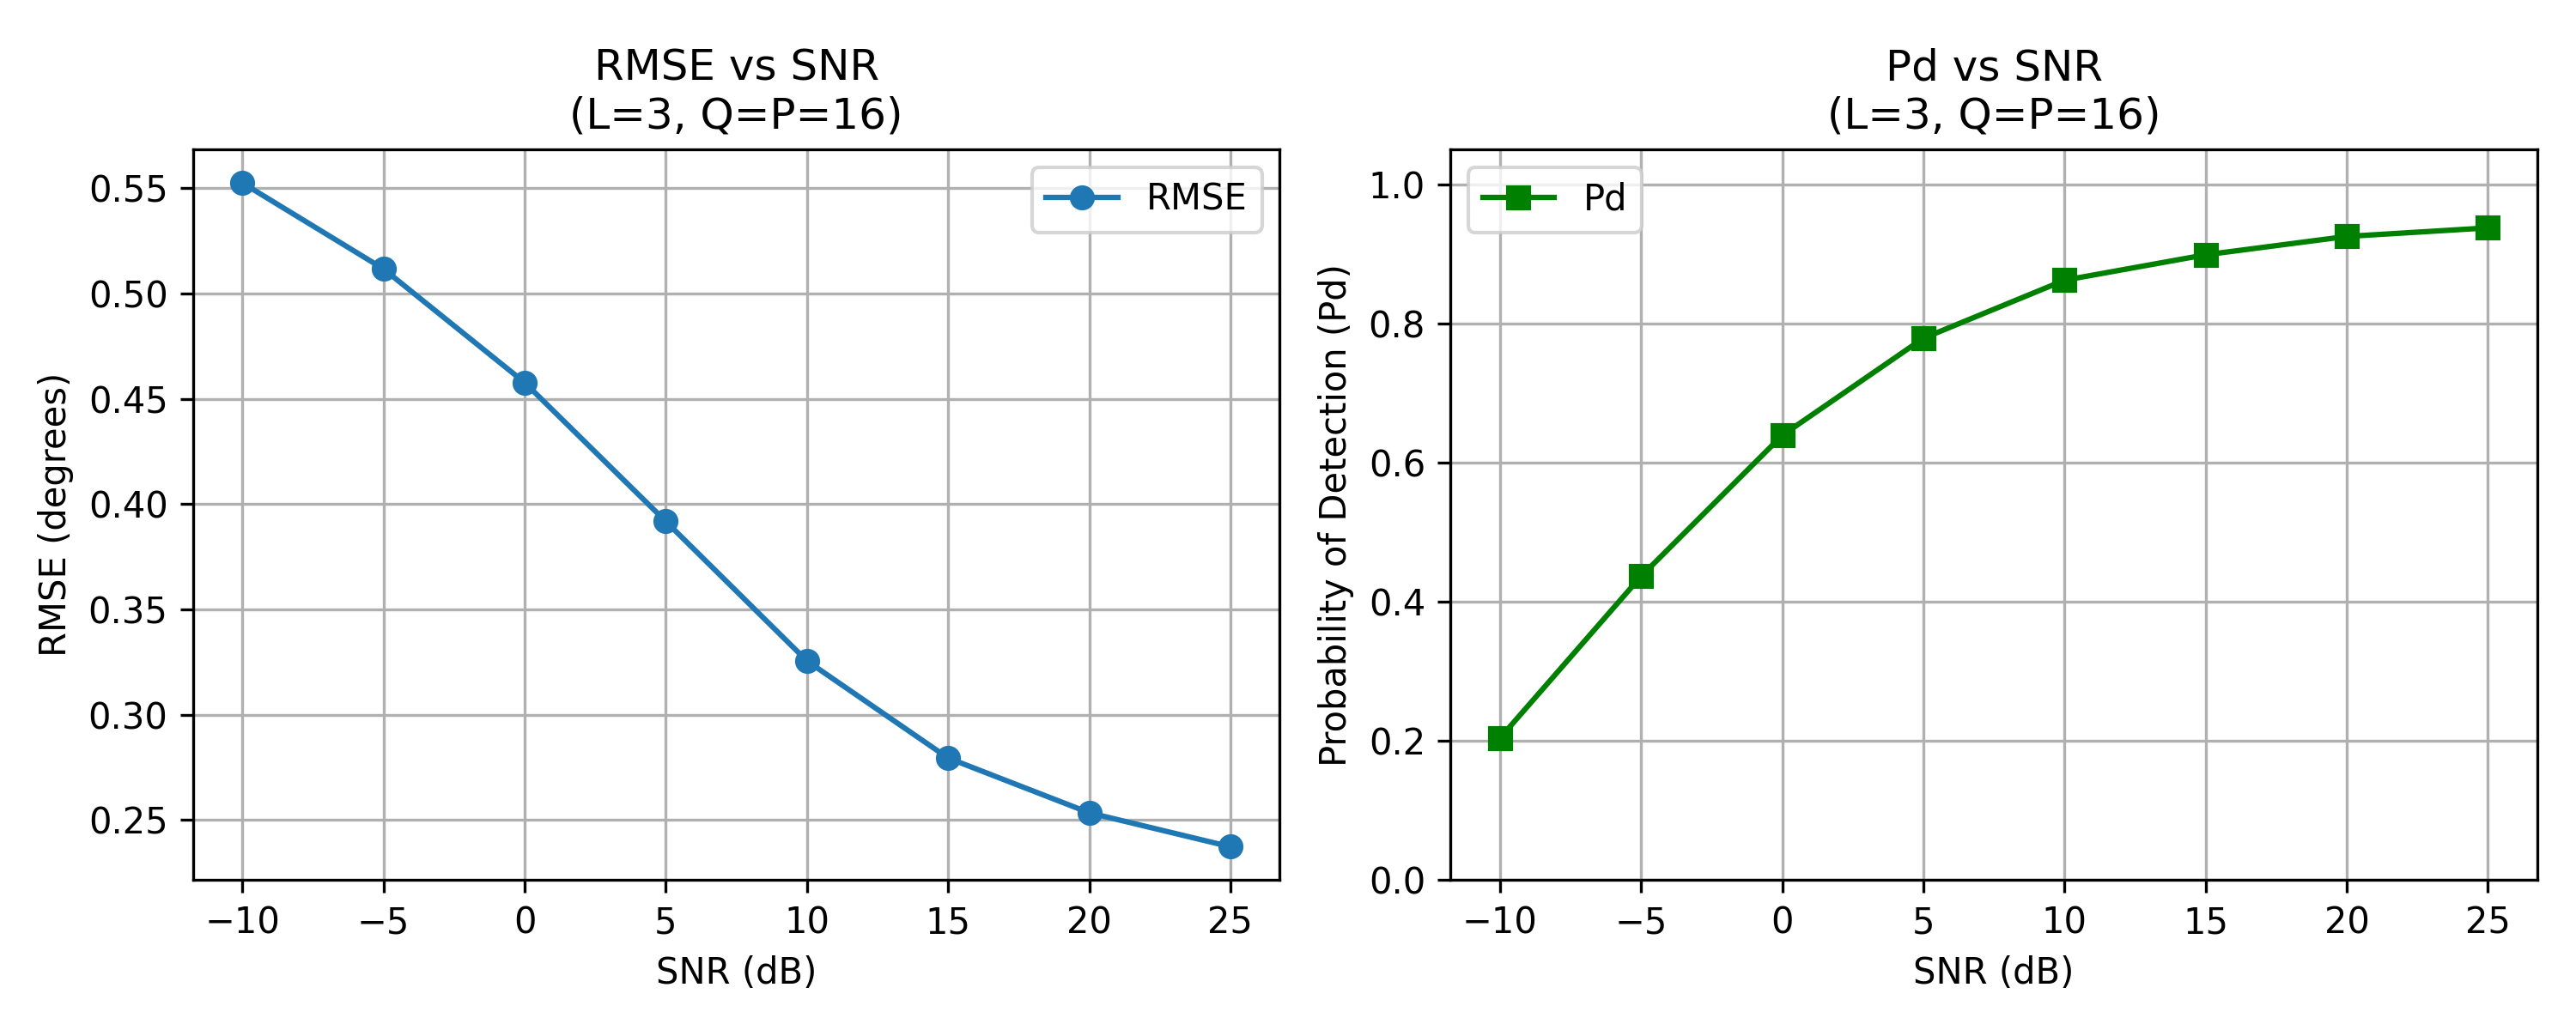

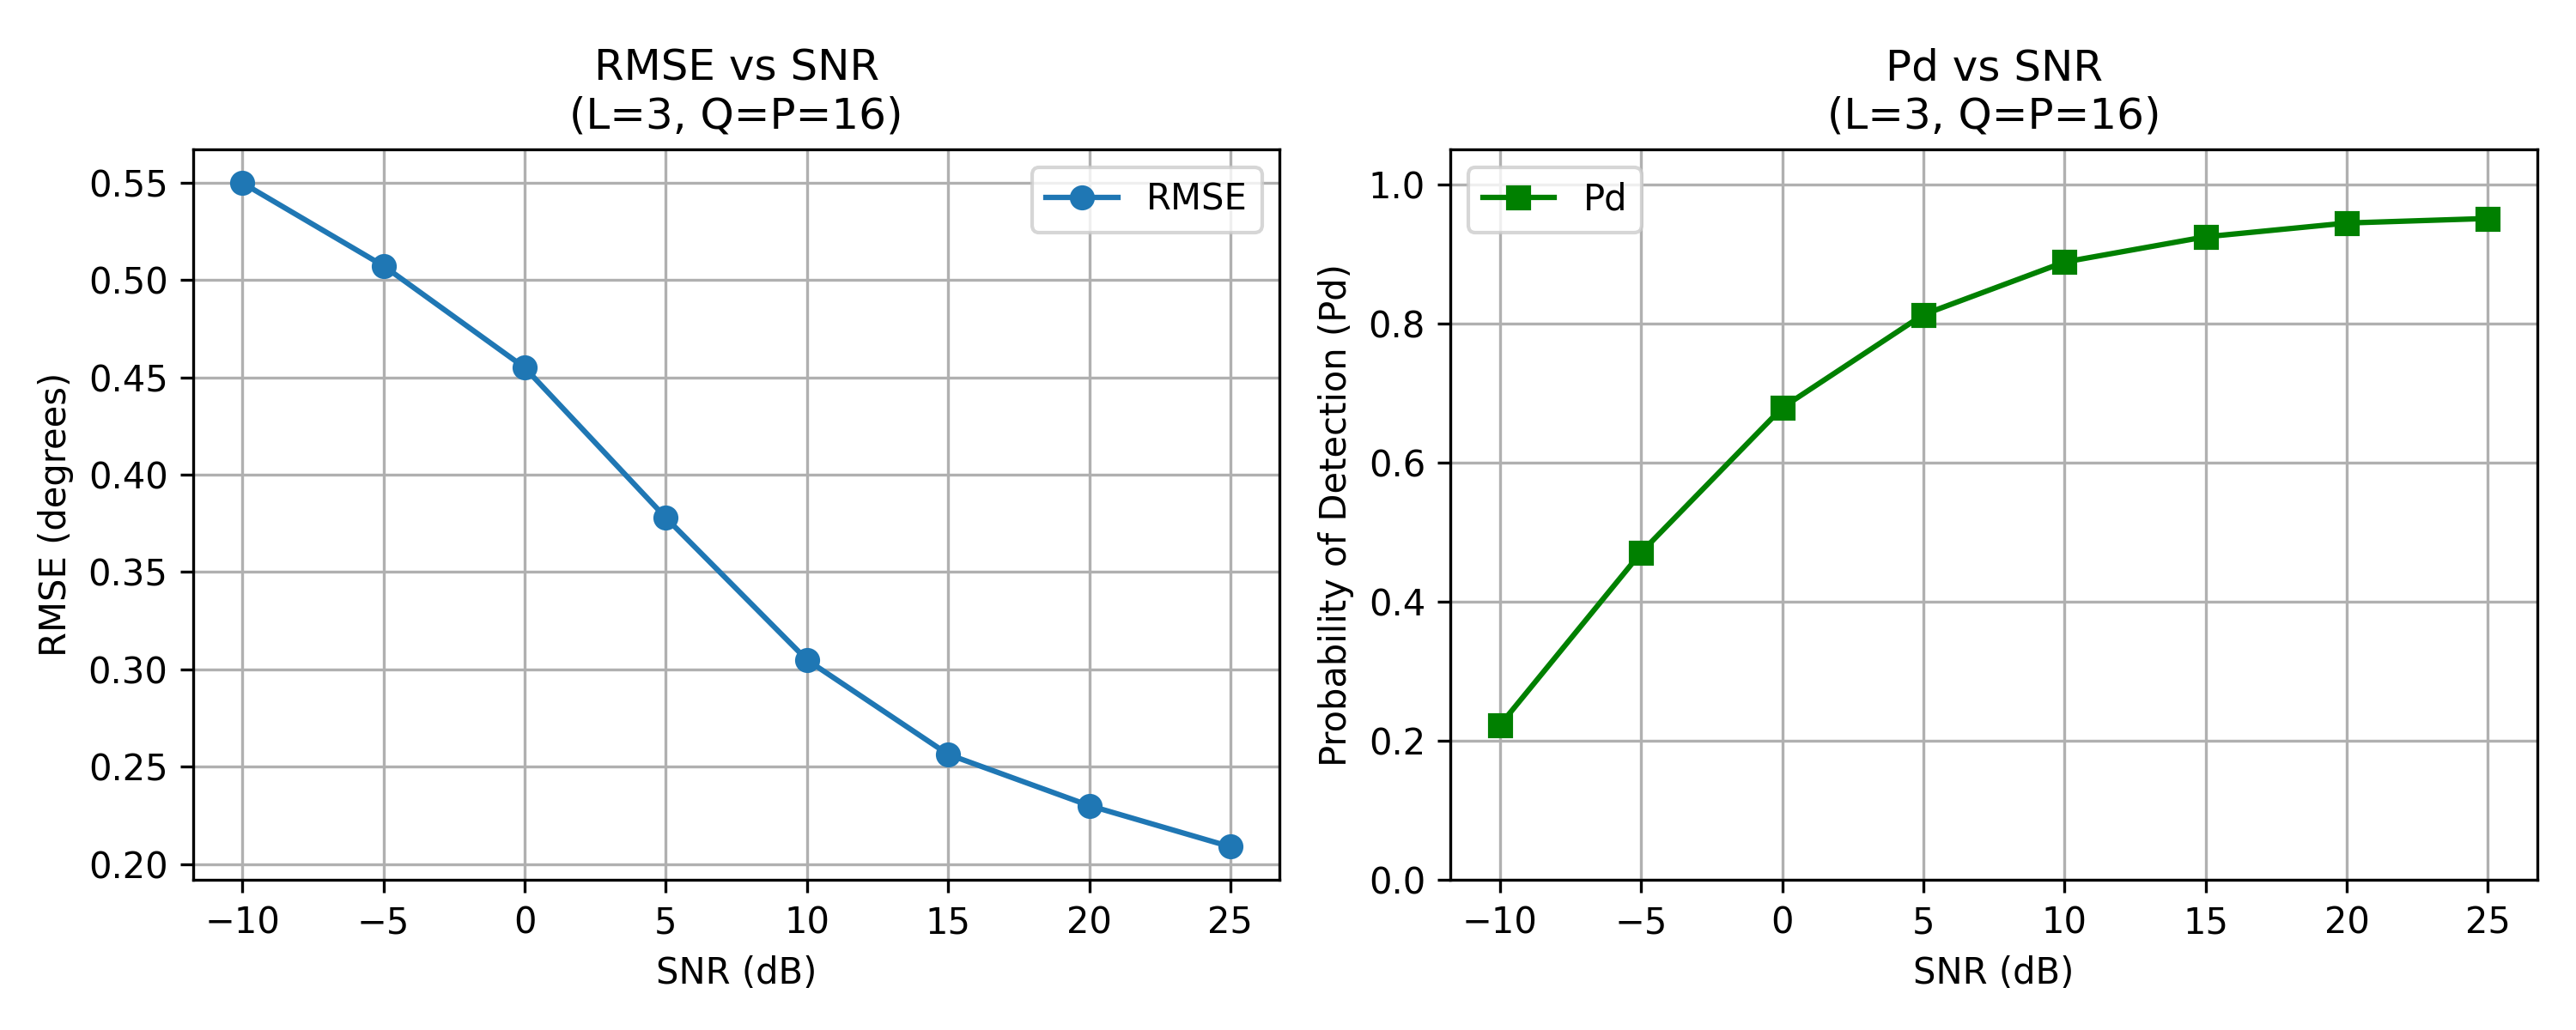

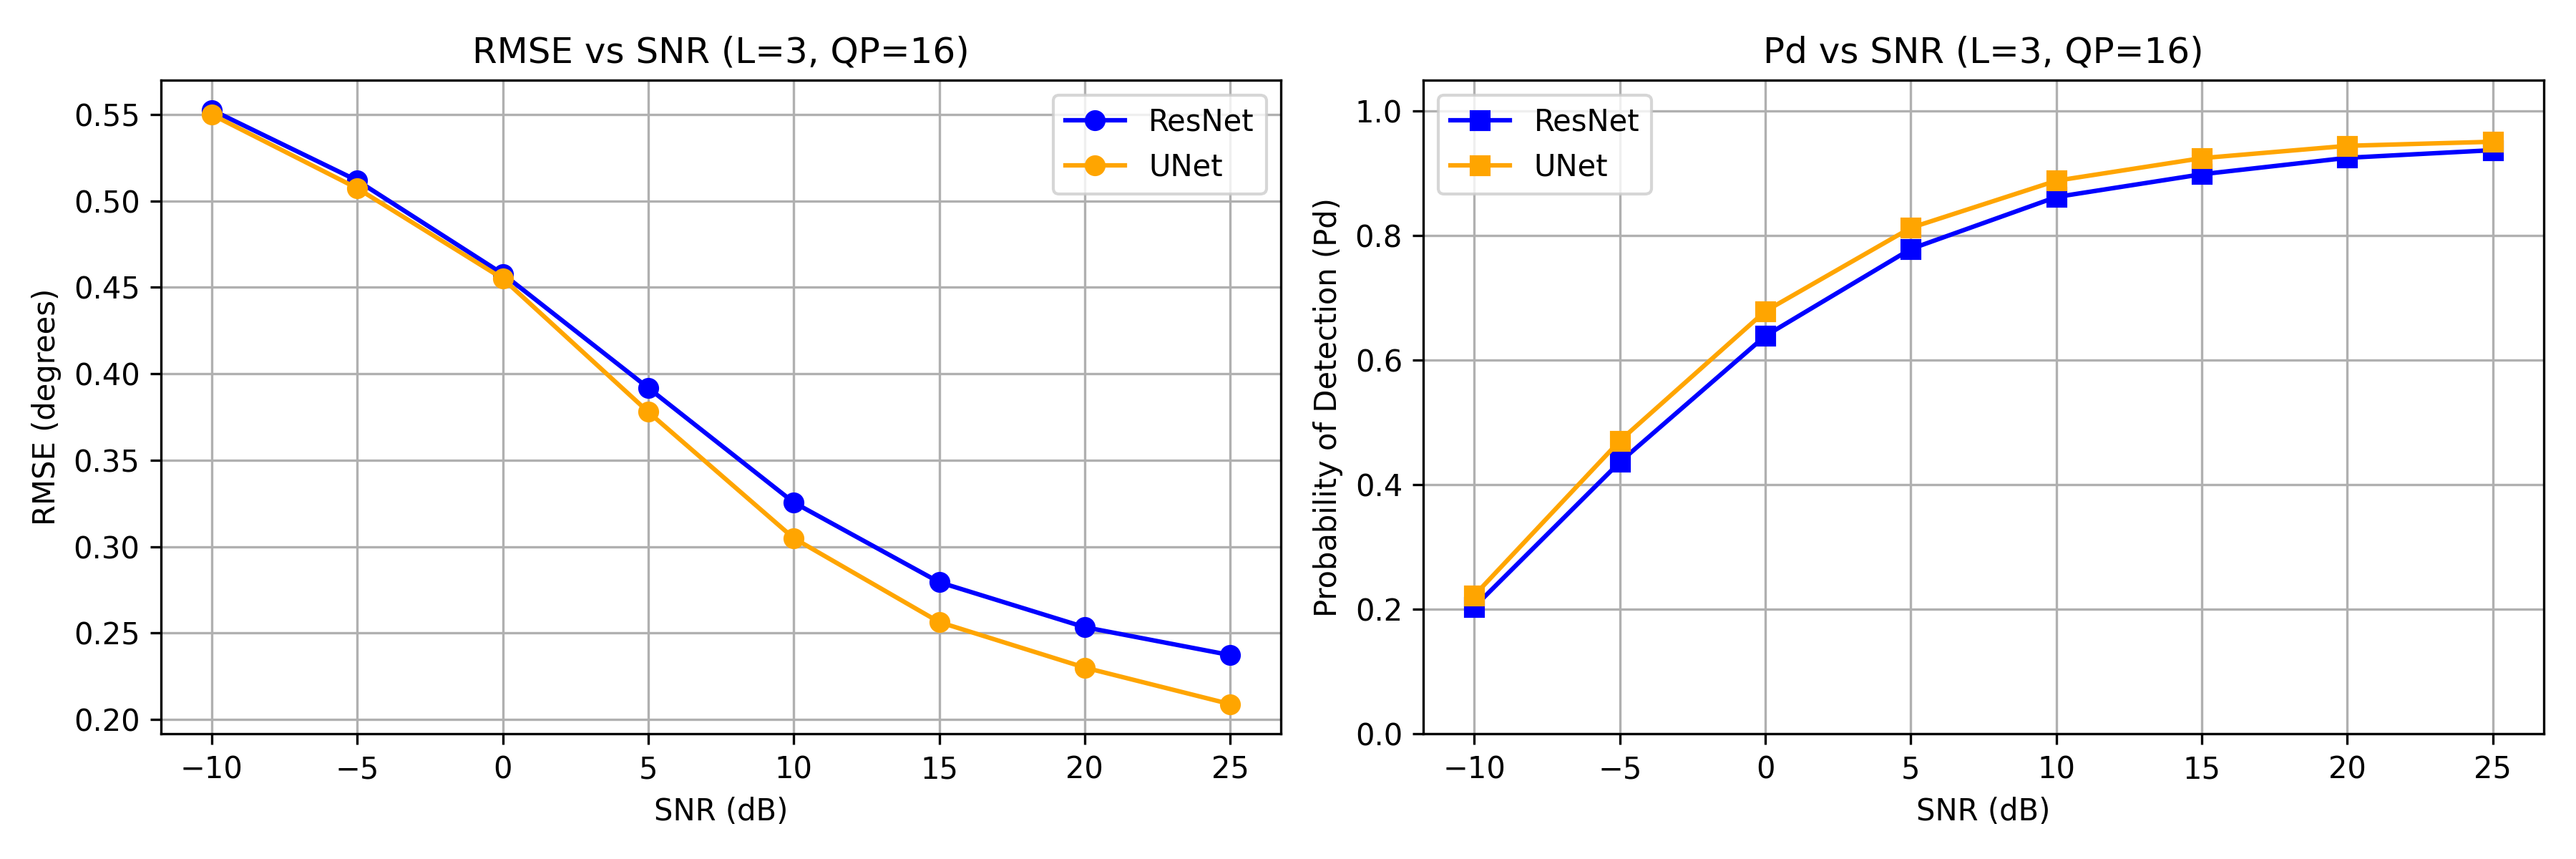

In [ ]:
from IPython.display import Image, display
display(Image(filename='figures_resnet/resnet_results.png'))
display(Image(filename='figures_unet/unet_results.png'))
display(Image(filename='figures_resnet_vs_unet/resnet_vs_unet_comparison.png'))

## Note

- Repo-te training loop-o ache (`dldoa_dataset_generation.py --mode train_resnet` / `train_unet`), jodi paper-er Table I hyperparameter (500 epoch, batch 32) diye notun kore train korte chao — kintu eta GPU chhara khub shomoy niye jabe.
- Pretrained model file gulo Colab-e download howar por local-e save korte chaile, `files.download('models/inf_model_007_256_unet.h5')` (from `google.colab import files`, cwd = `DL_DOA` dhore) use korte paro.